## Scenario 1: New checkout page (redo, full pipeline)

Business context: Your team wants to redesign the checkout page to reduce drop-off. Current conversion rate (visitor → completed purchase) has been steady at 12% over the last quarter. The team wants to detect at least a 12% relative lift before they'd consider it worth the engineering cost of keeping the new design. Standard org defaults: α=0.05, power=80%. The checkout page gets about 3,000 visitors/day, split 50/50 if you run the test.

Your task — work through this in order, before I give you any results:

State the hypotheses (H₀ and H₁, and whether you'd go one-tailed or two-tailed, with justification)
Pick the test you'd use, and justify why (walk the decision tree logic)
Convert the MDE from relative to absolute
Calculate the required sample size per group (describe your approach — formula, or ask me to run it once you've stated the inputs you'd plug in)
Figure out how many days the test would need to run given the daily traffic

## Answer - Step 1

1. stating the hypothesis-
H0: there is no diff btw the conversion rates of the old checkout page vs the new checkout page
H1: there is a significant increase/decrease in the checkout rate of the new page as compared to the old page

2. test selection -
- this looks like a 2 tailed test as we want to check for increase or decrease in conversion rate
- since this is a proportion of a binary metric we will use a 2 proportion z test or fishers exact test (depending on sample  size avaliable)

3. sample size calculations 
- alpha : 0.05 
- power : 80% 
- baseline : 12% 
- MDE : relative lift of 12 % ; meaning absolute lift of 1.44 % i.e. we need a 13.44% conversion rate


4. test duration 
- by calculation below we get it to be 5.6 rounding it up to 6 days 


In [38]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# ── Inputs ──
p1           = 0.12
relative_mde = 0.12
p2           = p1 * (1 + relative_mde)  # 0.1344
alpha        = 0.05
power        = 0.80

# z-scores — two-tailed: split α across both tails → use α/2
z_alpha = stats.norm.ppf(1 - alpha / 2)   # 1.96  (was 1.645 for one-tailed)
z_beta  = stats.norm.ppf(power)           # 0.842

# ── Method 1: Manual formula ──
numerator   = (z_alpha + z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))
denominator = (p2 - p1) ** 2
n_manual    = int(numerator / denominator) + 1

# ── Method 2: statsmodels ──
effect_size   = proportion_effectsize(p1, p2)
n_statsmodels = int(NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided'
)) + 1

print(f"p1 (baseline)  : {p1:.2%}")
print(f"p2 (target)    : {p2:.2%}  (+{p2-p1:.2%} absolute MDE)")
print(f"z_α (two-tail) : {z_alpha:.3f}   ← 1.96, not 1.645")
print(f"z_β            : {z_beta:.3f}")
print()
print(f"n per group — manual formula : {n_manual:,}")
print(f"n per group — statsmodels    : {n_statsmodels:,}")
print(f"Total users required         : {n_statsmodels * 2:,}")

p1 (baseline)  : 12.00%
p2 (target)    : 13.44%  (+1.44% absolute MDE)
z_α (two-tail) : 1.960   ← 1.96, not 1.645
z_β            : 0.842

n per group — manual formula : 8,401
n per group — statsmodels    : 8,399
Total users required         : 16,798


In [14]:
## test duration 
days_per_group = ((n_manual / 1500))  # assuming 1k users per day
days_per_group

5.600666666666666

ok now following up with prompt 2 : here is what we came up with after running the test for 6 days - 
Control: 8,500 visitors, 1,038 completed a purchase
Variant: 8,450 visitors, 1,124 completed a purchase

In [28]:
control_conversion = 1038/8500
test_conversion = 1124/8450
print(f"control conversion: {control_conversion:.2%}, test conversion: {test_conversion:.2%}")


# whats the observerd relative and absolute lift 
lift = (test_conversion - control_conversion) / control_conversion 
print(f"Observed relative lift: {lift:.2%}")

absolute_lift = test_conversion - control_conversion
print(f"Observed absolute lift: {absolute_lift:.2%}")   

control conversion: 12.21%, test conversion: 13.30%
Observed relative lift: 8.93%
Observed absolute lift: 1.09%


In [ ]:
    # passing the values into a 2 proportion z test formula
from statsmodels.stats.proportion import proportions_ztest

conversions = [1038, 1124]          # [control, treatment]
n_obs       = [8500, 8450]          # [control n, treatment n]

z_stat, p_value = proportions_ztest(conversions, n_obs,
alternative='two-sided')

print(f"z-statistic : {z_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print()

if p_value < alpha:
    print(f"Reject H₀  (p = {p_value:.4f} < α = {alpha})")
else:
    print(f"Fail to reject H₀  (p = {p_value:.4f} ≥ α = {alpha})")




z-statistic : -2.1270
p-value     : 0.0334

Reject H₀  (p = 0.0334 < α = 0.05)


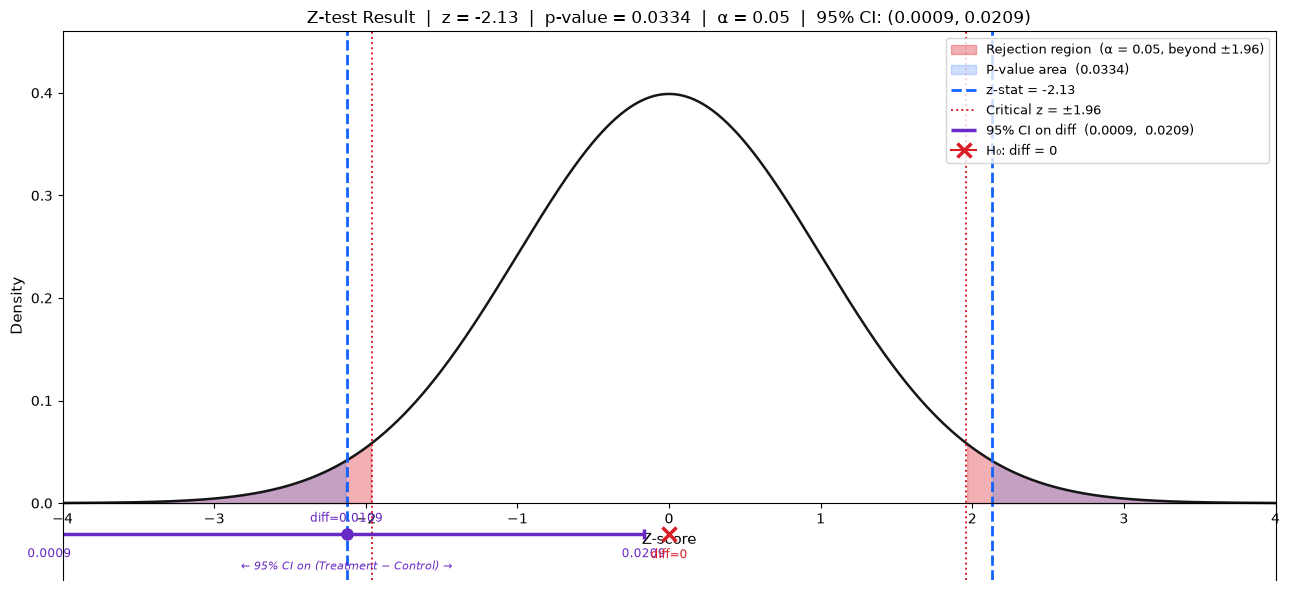

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import confint_proportions_2indep

# ── CI on the difference (treatment − control) ──
control_n, treatment_n     = 8500, 8450
control_conv, treatment_conv = 1038, 1124

ci_lower, ci_upper = confint_proportions_2indep(
    treatment_conv, treatment_n,
    control_conv,   control_n,
    method='wald'
)

# CI in z-score space: always z_stat ± z_critical
z_critical = stats.norm.ppf(1 - alpha / 2)   # 1.96
ci_lower_z = z_stat - z_critical
ci_upper_z = z_stat + z_critical
diff       = test_conversion - control_conversion

fig, ax = plt.subplots(figsize=(13, 6))

x = np.linspace(-4, 4, 1000)
ax.plot(x, stats.norm.pdf(x), color='#161616', linewidth=1.8)

# Rejection regions (red)
for x_tail in [x[x <= -z_critical], x[x >= z_critical]]:
    lbl = f'Rejection region  (α = {alpha}, beyond ±{z_critical:.2f})' if x_tail[0] < 0 else '_'
    ax.fill_between(x_tail, stats.norm.pdf(x_tail), color='#da1e28', alpha=0.35, label=lbl)

# P-value area (blue)
for x_tail in [x[x <= -abs(z_stat)], x[x >= abs(z_stat)]]:
    lbl = f'P-value area  ({p_value:.4f})' if x_tail[0] < 0 else '_'
    ax.fill_between(x_tail, stats.norm.pdf(x_tail), color='#0f62fe', alpha=0.20, label=lbl)

# Z-statistic
ax.axvline( z_stat, color='#0f62fe', linewidth=2, linestyle='--', label=f'z-stat = {z_stat:.2f}')
ax.axvline(-z_stat, color='#0f62fe', linewidth=2, linestyle='--')

# Critical value boundaries
ax.axvline( z_critical, color='#da1e28', linewidth=1.4, linestyle=':', label=f'Critical z = ±{z_critical:.2f}')
ax.axvline(-z_critical, color='#da1e28', linewidth=1.4, linestyle=':')

# 95% CI bar (purple)
ci_y = -0.03
ax.hlines(ci_y, ci_lower_z, ci_upper_z, color='#6929c4', linewidth=2.5,
          label=f'95% CI on diff  ({ci_lower:.4f},  {ci_upper:.4f})')
ax.vlines([ci_lower_z, ci_upper_z], ci_y - 0.005, ci_y + 0.005, color='#6929c4', linewidth=2.5)
ax.plot(z_stat, ci_y, 'o', color='#6929c4', markersize=8, zorder=5)
ax.plot(0, ci_y, marker='x', color='#da1e28', markersize=10, markeredgewidth=2.5,
        zorder=5, label='H₀: diff = 0')

ax.text(ci_lower_z, ci_y - 0.014, f'{ci_lower:.4f}', ha='center', va='top', fontsize=8.5, color='#6929c4')
ax.text(ci_upper_z, ci_y - 0.014, f'{ci_upper:.4f}', ha='center', va='top', fontsize=8.5, color='#6929c4')
ax.text(z_stat,     ci_y + 0.009, f'diff={diff:.4f}', ha='center', va='bottom', fontsize=8.5, color='#6929c4')
ax.text(0,          ci_y - 0.014, 'diff=0', ha='center', va='top', fontsize=8.5, color='#da1e28')
ax.text((ci_lower_z + ci_upper_z) / 2, ci_y - 0.026,
        '← 95% CI on (Treatment − Control) →',
        ha='center', va='top', fontsize=8, color='#6929c4', style='italic')

ax.set_ylim(-0.075, 0.46)
ax.set_xlim(-4, 4)
ax.set_xlabel('Z-score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Z-test Result  |  z = {z_stat:.2f}  |  p-value = {p_value:.4f}  |  α = {alpha}  |  '
    f'95% CI: ({ci_lower:.4f}, {ci_upper:.4f})',
    fontsize=12
)
ax.legend(fontsize=9, loc='upper right')
ax.spines['bottom'].set_position(('data', 0))

plt.tight_layout()
plt.show()

### interpretation of the results

1. **p-value vs α — is the result real or noise?**
  - p < 0.05 → the difference is statistically significant

  unlikely to be random ( and since here p = 0.0334 < α = 0.05 we can say that the results are statistically significant that is they are not due to radomness in the data)

2. **Direction and size — is it worth acting on?**
  Q: which way did it move ?
  since treatment conversion rate > control conversion rate and it is good in this case so i would say that this is good

  Q: is the absolute lift >= MDE ?
  absolute lift here is 1.09% which is less than the MDE of 1.44 % 
  insight : A significant result that's below your MDE means the effect is real but too small to justify the engineering cost (the relative lift in this case is : 8.93% vs the business requirement of 12%)


3. **CI — what's the range of plausible true effects?**
    CI here is : 0.09%- 2.09%

    now the way to read this is : "We're 95% confident the true lift is somewhere between 0.09pp and 2.09pp"
    and 95% confidence is there because the alpha is 0.05 in this case
  

  - CI excludes zero → consistent with significance (should always agree with p-value)
  - CI lower bound > MDE → even the pessimistic end beats your bar, high confidence to ship
  - CI lower bound < MDE but upper > MDE → significant but uncertain, the true effect might be below your bar — consider   running longer
  - CI entirely below MDE → statistically significant but practically meaningless, do not ship






  4. CONCLUSION :
  onclusion: Do Not Ship — yet.

  The new checkout page produced a real, statistically
  significant lift. But it fell short of the MDE the team set.
  You have two honest options to bring back to the PM:

  - Re-run with more data — the effect might be real but you
  were slightly underpowered to detect something this close to
  the MDE boundary. A longer run gives the CI more precision.
  - Revisit the MDE — if the team would actually be happy with a
   ~1pp lift given the engineering cost, lower the bar and
  re-evaluate. But that conversation has to happen before you
  look at the results, not after.

  What you cannot do is declare it a win because p < 0.05 — the
  business bar was the MDE, not just significance.


## Scenario 2 : Ad creative CTR test
You're testing a new ad creative (Variant B) against the current one (Control A). Your metric is click-through rate (CTR) = clicks / impressions.

Business setup:

Current baseline CTR: 3%
You want to detect at least a 15% relative lift (i.e., meaningfully better than baseline)
α = 0.05, power = 80%
Traffic: ad server delivers ~5,000 impressions/day to each variant

Steps:
1. Define hypotheses — H0/H1, including one-tailed vs. two-tailed, and identify your metric type (proportion / mean / count / categorical)
2. Define MDE — the minimum effect size that would matter to the business
3. Calculate required sample size — using the formula that matches your test type from step 1
4. Convert to duration — based on daily traffic
5. Define guardrail metrics — what shouldn't get worse, decided before you look at any data
6. Run the test — collect data to the pre-registered n, no early peeking
7. Test the hypothesis — run the actual statistical test once, at the planned stopping point
8. Interpret and conclude — statistical significance + practical significance (vs. MDE) + guardrail check + recommendation

## Answer — Step 1: Hypotheses

**Metric type:** CTR = clicks / impressions → proportion of a binary outcome (each impression either gets a click or doesn't) → **two-proportion z-test**

---

**H₀:** CTR of Variant B <= CTR of Control A  *(no difference)*

**H₁:** CTR of Variant B > CTR of Control A  *(new creative has higher CTR)*

---

**One-tailed or two-tailed?**

**One-tailed.** The goal is specifically to detect an *improvement* in CTR. If Variant B doesn't beat Control A, we revert — a drop doesn't change that decision, so there's no need to test both directions. One-tailed also gives a smaller required sample size, meaning a shorter test for the same α and power.

---

**Statistical parameters:**

| Parameter | Value |
|---|---|
| Baseline CTR (p1) | 3% |
| Relative MDE | 15% lift |
| Absolute MDE | 3% × 1.15 = **3.45%** (+0.45pp) |
| α | 0.05 (one-tailed) |
| Power | 80% |
| Daily traffic per group | 5,000 impressions |

In [34]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# ── Inputs ──
p1           = 0.03
relative_mde = 0.15
p2           = p1 * (1 + relative_mde)  # 0.0345
alpha        = 0.05
power        = 0.80

# z-scores — one-tailed
z_alpha = stats.norm.ppf(1 - alpha)    # 1.645
z_beta  = stats.norm.ppf(power)        # 0.842

# ── Method 1: Manual formula ──
numerator   = (z_alpha + z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))
denominator = (p2 - p1) ** 2
n_manual    = int(numerator / denominator) + 1

# ── Method 2: statsmodels ──
# abs() needed — proportion_effectsize returns negative when p2 > p1
effect_size   = abs(proportion_effectsize(p1, p2))
n_statsmodels = int(NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=power, alternative='larger'
)) + 1

print(f"p1 (baseline CTR)  : {p1:.2%}")
print(f"p2 (target CTR)    : {p2:.2%}  (+{p2-p1:.2%} absolute MDE)")
print(f"z_α (one-tail)     : {z_alpha:.3f}")
print(f"z_β                : {z_beta:.3f}")
print()
print(f"n per group — manual formula : {n_manual:,}")
print(f"n per group — statsmodels    : {n_statsmodels:,}")
print(f"Total impressions required   : {n_statsmodels * 2:,}")
print()
print(f"Daily traffic per group      : 5,000 impressions")
print(f"Days needed                  : {n_statsmodels / 5000:.1f} days  (~{int(np.ceil(n_statsmodels / 5000))} full days)")

p1 (baseline CTR)  : 3.00%
p2 (target CTR)    : 3.45%  (+0.45% absolute MDE)
z_α (one-tail)     : 1.645
z_β                : 0.842

n per group — manual formula : 19,055
n per group — statsmodels    : 19,035
Total impressions required   : 38,070

Daily traffic per group      : 5,000 impressions
Days needed                  : 3.8 days  (~4 full days)


## Step 5 — Guardrail Metric: Cost Per Click (CPC)

CPC = total ad spend / total clicks

If the new creative drives more clicks but attracts lower-quality traffic, CPC could rise even as CTR improves — making the campaign less efficient overall.

**Rule (decided before looking at results):** CPC for Variant B must not be significantly higher than Control A. If CTR improves but CPC rises beyond an acceptable threshold, the result is not a clean win.

these are the results:
Control: 19,842 impressions, 601 clicks
Variant: 20,156 impressions, 683 clicks

In [36]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

control_impressions  = 19842
control_clicks       = 601
variant_impressions  = 20156
variant_clicks       = 683

control_ctr = control_clicks / control_impressions
variant_ctr = variant_clicks / variant_impressions

lift_abs = variant_ctr - control_ctr
lift_rel = lift_abs / control_ctr

print(f"Control CTR  : {control_ctr:.4f}  ({control_ctr:.2%})")
print(f"Variant CTR  : {variant_ctr:.4f}  ({variant_ctr:.2%})")
print(f"Absolute lift: {lift_abs:+.4f}  ({lift_abs*100:+.2f} pp)")
print(f"Relative lift: {lift_rel:+.2%}")
print(f"MDE target   : +{(p2-p1)*100:.2f} pp  ({relative_mde:.0%} relative)")

# ── Z-test (one-tailed) ──
z_stat, p_value = proportions_ztest(
    [control_clicks, variant_clicks],
    [control_impressions, variant_impressions],
    alternative='smaller'   # one-tailed: H₁ variant > control → control is 'smaller'
)

print(f"\nz-statistic  : {z_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
print()
if p_value < alpha:
    print(f"Reject H₀  (p = {p_value:.4f} < α = {alpha})  — statistically significant")
else:
    print(f"Fail to reject H₀  (p = {p_value:.4f} ≥ α = {alpha})")

# ── 95% CI on difference ──
ci_lower, ci_upper = confint_proportions_2indep(
    variant_clicks, variant_impressions,
    control_clicks, control_impressions,
    method='wald'
)
print(f"\n95% CI on diff: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"CI excludes 0? : {'YES' if ci_lower > 0 else 'NO — zero is plausible'}")
print(f"CI lower ≥ MDE?: {'YES' if ci_lower >= (p2-p1) else 'NO — pessimistic end is below MDE'}")

Control CTR  : 0.0303  (3.03%)
Variant CTR  : 0.0339  (3.39%)
Absolute lift: +0.0036  (+0.36 pp)
Relative lift: +11.87%
MDE target   : +0.45 pp  (15% relative)

z-statistic  : -2.0402
p-value      : 0.0207

Reject H₀  (p = 0.0207 < α = 0.05)  — statistically significant

95% CI on diff: (0.0001, 0.0070)
CI excludes 0? : YES
CI lower ≥ MDE?: NO — pessimistic end is below MDE


### interpretation of results

since p < alpha i would reject the null meaning that there is a significant diff between variant and control (and the variant is significant ly higher than the control)

a CI of [0.01pp - 0.7pp] indicates that the real lift can be anywhere from 0.01pp to 0.7pp so we need to run the test longer again to say with more confidence that this is the case (statistically significant but not confidently proven to hit the practical bar" situation)

**also remember : 
  But the CI itself is always on the absolute difference scale.
  You can't directly build a CI on relative lift without more
  work (it requires the delta method), and in practice nobody
  does — you just report the absolute CI and mention the relative
   lift separately.

###  Ship vs No-Ship Checklist

Run through in order. **All Ship boxes must be checked to ship.**

| # | Check | Ship ✅ | No-Ship ❌ |
|---|---|---|---|
| 1 | p-value vs α | p < α | p ≥ α → stop here, do not ship |
| 2 | Direction | Metric moved the right way | Metric moved the wrong way → do not ship |
| 3 | Absolute lift vs MDE | lift ≥ MDE | lift < MDE → effect real but too small |
| 4 | CI excludes zero | Yes | No → zero is plausible, run longer |
| 5 | CI lower bound vs MDE | CI lower ≥ MDE | CI lower < MDE → uncertain, run longer |
| 6 | Guardrail metrics | None breached | Any guardrail breached → do not ship regardless |

---

**Scenario 2 scorecard:**

| # | Check | Result |
|---|---|---|
| 1 | p < α | ✅  p = 0.021 < 0.05 |
| 2 | Direction | ✅  variant CTR > control CTR |
| 3 | lift ≥ MDE | ❌  +0.36pp < MDE of +0.45pp |
| 4 | CI excludes zero | ✅  (0.0001, 0.0070) |
| 5 | CI lower ≥ MDE | ❌  0.0001pp << 0.45pp |
| 6 | Guardrail (CPC) | ⚠️  not yet checked |

**Verdict: Do Not Ship — yet.** Significant but lift and CI lower bound both fall short of MDE. Run longer or revisit MDE with PM.

## did not understand the below (scenario 3) - need to check the code and understand it

## Scenario 3: Streaming Recommendation Algorithm Test 
A video streaming company is testing 3 different recommendation algorithms to see which drives more engagement:

A (Control): current algorithm
B: new collaborative-filtering approach
C: new deep-learning approach
Metric: average watch time per user per week (in minutes), measured over a 3-week test period.
Some context that matters:

Watch time data is famously right-skewed — most users watch a modest amount, but a small number of binge-watchers rack up huge hours, dragging the distribution's tail out
This is a brand-new feature area — no prior A/B test has run on recommendation algorithms before, so there's no historical variance estimate sitting around
Leadership is nervous about one specific thing: maybe users are just curious about the new recommendations and click around more in week 1, and it fades by week 3 — they specifically want your test design to be able to catch that if it happens
Traffic: ~10,000 active users/week, split evenly across the 3 arms
Your task — walk through as much as you can, and flag where you're unsure:

What test family fits here, given 3 groups and a continuous metric — and what do you do about the skew?
How would you get a variance estimate for the sample size calc, given there's no historical data for this exact metric?
How would you design the test to specifically catch/rule out a novelty effect, given leadership's concern?

Steps:
1. Define hypotheses — H0/H1, including one-tailed vs. two-tailed, and identify your metric type (proportion / mean / count / categorical)
2. Define MDE — the minimum effect size that would matter to the business
3. Calculate required sample size — using the formula that matches your test type from step 1
4. Convert to duration — based on daily traffic
5. Define guardrail metrics — what shouldn't get worse, decided before you look at any data
6. Run the test — collect data to the pre-registered n, no early peeking
7. Test the hypothesis — run the actual statistical test once, at the planned stopping point
8. Interpret and conclude — statistical significance + practical significance (vs. MDE) + guardrail check + recommendation

hypothesis :
H₀: mean watch time is equal across all three algorithms (μ_A = μ_B = μ_C)
H₁: at least one algorithm produces a different mean watch time


now the test i will use here is ANOVA as n > 30 ( we do have a lot of samples with us lol)


## After Hypothesis — What Comes Next

### Step 2: Variance Estimate

No historical data exists, but we don't need a pilot. Since group A is the **current algorithm running under normal conditions**, we use the **control arm's variance** from week 1 of the test itself.

```
Week 1 → collect watch time from control arm only
       → compute variance from that sample
       → plug into sample size formula
       → never look at treatment arms yet  (avoids peeking)
Week 2-3 → run full test across all 3 arms
         → analyse once at the pre-specified stopping point
```

### Step 3: Sample Size

For ANOVA with 3 groups we use **Cohen's f** as the effect size:

```
f = σ_means / σ_within
```

- `σ_means` — std dev of the group means you want to detect
- `σ_within` — within-group std dev (taken from the control arm in week 1)

Use `statsmodels FTestAnovaPower` to solve for n per group given f, α, power, and k=3.

### Step 4: Test Duration

```
users_per_arm_per_week = 10,000 / 3  ≈ 3,333
weeks_needed = n_per_group / 3,333
```

Leadership wants 3 weeks — verify required n is met within that window.

### Step 5: Guardrail Metrics (decided before looking at results)

- **Retention rate** — watch time up but users churning more = bad trade-off
- **Skip rate** — users skipping more signals poor quality, not real engagement

### Step 6: Novelty Effect Design

Track watch time **week-by-week per arm** across all 3 weeks:

- Week-1 lift that decays back to control by week 3 → **novelty effect, not a real improvement**
- Sustained or growing lift across all 3 weeks → **genuine improvement**

This weekly breakdown is the specific design choice that answers leadership's concern.

### Step 7: Handling Skew

Right-skewed watch time → **log-transform before running ANOVA**. Compresses the long tail and brings the distribution closer to normal. With ~3,333 users per arm the CLT helps too, but log-transforming is still best practice for watch time data.

If skew remains extreme after transformation → switch to **Kruskal-Wallis** (non-parametric ANOVA equivalent, tests medians, no normality assumption).

### Step 8: Multiple Comparisons After ANOVA

ANOVA tells you *something* differs — not *which pair*. If H₀ is rejected, follow up with **Tukey's HSD** pairwise tests. This controls the family-wise error rate so three pairwise comparisons don't inflate your false positive rate above α.

Power of the test :


In [48]:
import numpy as np
from statsmodels.stats.power import FTestAnovaPower

# ── Assumptions ──
# sigma_within comes from the control arm in week 1.
# For planning we use a reasonable estimate for a streaming platform.
k             = 3        # number of groups
alpha         = 0.05
power         = 0.80
sigma_within  = 80       # within-group std dev (minutes/week) — from control arm
weekly_users  = 10_000
users_per_arm = weekly_users / k   # ~3,333

# ── Expected means — what difference do we want to detect? ──
# Conservative case: only one arm improves, the other stays at control level.
mu_A = 120   # control (current algorithm)
mu_B = 135   # collaborative filtering — target lift +15 min/week
mu_C = 120   # deep learning — same as control (worst case)

means       = np.array([mu_A, mu_B, mu_C])
grand_mean  = means.mean()
sigma_means = np.sqrt(((means - grand_mean) ** 2).mean())

# Cohen's f = sigma_means / sigma_within
cohens_f = sigma_means / sigma_within

print(f'Group means          : A={mu_A}, B={mu_B}, C={mu_C} min/week')
print(f'Grand mean           : {grand_mean:.1f}')
print(f'sigma_means          : {sigma_means:.2f}')
print(f'sigma_within         : {sigma_within}')
print(f"Cohen's f            : {cohens_f:.4f}  (small~0.10, medium~0.25, large~0.40)")
print()

# ── Sample size ──
analysis    = FTestAnovaPower()
n_per_group = analysis.solve_power(
    effect_size=cohens_f, alpha=alpha, power=power, k_groups=k
)
n_per_group = int(n_per_group) + 1
weeks_needed = n_per_group / users_per_arm

print(f'Required n per group : {n_per_group:,}')
print(f'Total users required : {n_per_group * k:,}')
print()
print(f'Users per arm/week   : {users_per_arm:,.0f}')
print(f'Weeks needed         : {weeks_needed:.1f}  (leadership wants 3 weeks)')
print()
if weeks_needed <= 3:
    print('V 3-week window is sufficient')
else:
    print(f'X Need {weeks_needed:.1f} weeks — either reduce MDE or extend the test')


Group means          : A=120, B=135, C=120 min/week
Grand mean           : 125.0
sigma_means          : 7.07
sigma_within         : 80
Cohen's f            : 0.0884  (small~0.10, medium~0.25, large~0.40)

Required n per group : 1,237
Total users required : 3,711

Users per arm/week   : 3,333
Weeks needed         : 0.4  (leadership wants 3 weeks)

V 3-week window is sufficient


## Step 6-8: Simulate Data & Full Analysis

We simulate 3 weeks of right-skewed watch time data for each arm, then run the full pipeline.

In [45]:
import numpy as np
import pandas as pd
np.random.seed(42)

# ── Simulate right-skewed watch time (log-normal) ──
# log-normal: exp(normal(mu, sigma)) gives right-skewed positive data
n_per_arm = n_per_group   # from sample size cell
n_weeks   = 3

# True underlying means (minutes/week): A=120, B=135 sustained, C=novelty effect
# C spikes week 1 then fades back — simulating a novelty effect
weekly_means = {
    'A_control':  [120, 120, 120],
    'B_collab':   [135, 135, 135],   # genuine sustained lift
    'C_deep':     [140, 125, 118],   # novelty: big week 1, fades below control
}

rows = []
for arm, means in weekly_means.items():
    for week, mu in enumerate(means, 1):
        # log-normal with target mean mu and std dev ~80
        sigma_ln = np.sqrt(np.log(1 + (80/mu)**2))
        mu_ln    = np.log(mu) - sigma_ln**2 / 2
        watch    = np.random.lognormal(mu_ln, sigma_ln, n_per_arm)
        for w in watch:
            rows.append({'arm': arm, 'week': week, 'watch_time': w})

df = pd.DataFrame(rows)
print(df.groupby(['arm', 'week'])['watch_time'].agg(['mean','std','count']).round(1))

                 mean   std  count
arm       week                    
A_control 1     123.0  83.4   1237
          2     120.7  77.9   1237
          3     122.2  84.0   1237
B_collab  1     129.6  74.8   1237
          2     133.7  82.7   1237
          3     135.3  83.9   1237
C_deep    1     142.4  85.5   1237
          2     122.7  71.8   1237
          3     114.0  71.7   1237


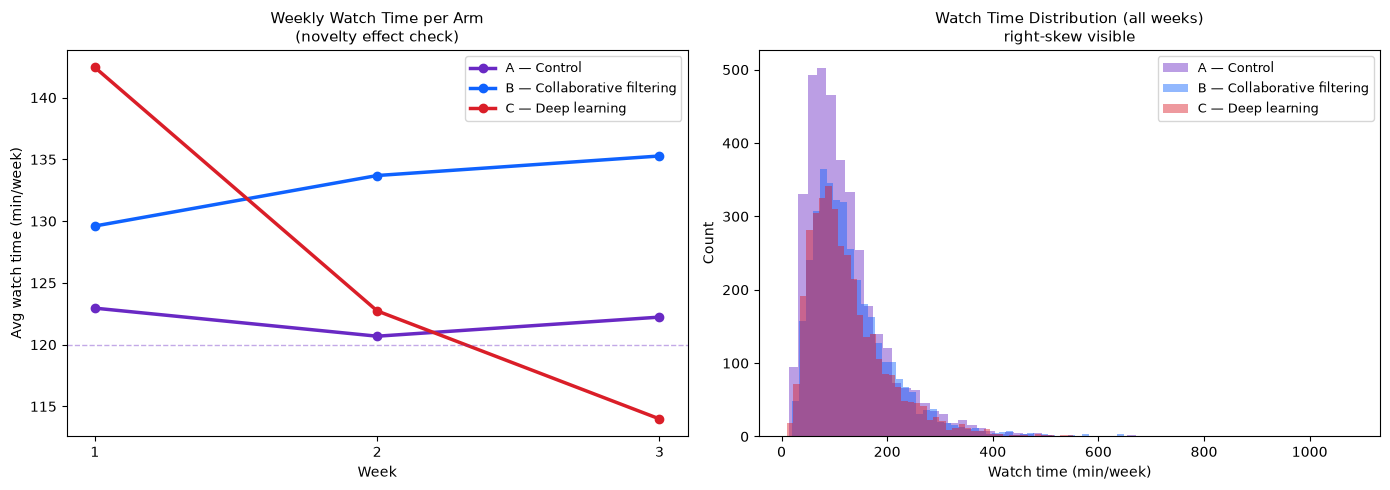

In [49]:
import matplotlib.pyplot as plt
from scipy import stats

# ── Novelty effect: weekly trend plot ──
weekly_avg = df.groupby(['arm','week'])['watch_time'].mean().reset_index()

colors = {'A_control': '#6929c4', 'B_collab': '#0f62fe', 'C_deep': '#da1e28'}
labels = {'A_control': 'A — Control', 'B_collab': 'B — Collaborative filtering', 'C_deep': 'C — Deep learning'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: weekly trends
for arm in weekly_avg['arm'].unique():
    d = weekly_avg[weekly_avg['arm'] == arm]
    axes[0].plot(d['week'], d['watch_time'], marker='o', linewidth=2.5,
                 color=colors[arm], label=labels[arm])

axes[0].axhline(120, color='#6929c4', linewidth=1, linestyle='--', alpha=0.4)
axes[0].set_title('Weekly Watch Time per Arm\n(novelty effect check)', fontsize=11)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Avg watch time (min/week)')
axes[0].set_xticks([1, 2, 3])
axes[0].legend(fontsize=9)

# Right: overall distribution (all weeks combined)
for arm in df['arm'].unique():
    axes[1].hist(df[df['arm']==arm]['watch_time'], bins=60, alpha=0.45,
                 color=colors[arm], label=labels[arm])

axes[1].set_title('Watch Time Distribution (all weeks)\nright-skew visible', fontsize=11)
axes[1].set_xlabel('Watch time (min/week)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [50]:
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Use all-week data (aggregate per user across weeks for independence) ──
user_total = df.groupby(['arm', df.groupby('arm').cumcount()])['watch_time'].sum().reset_index()
user_avg   = df.groupby(['arm', df.index // n_weeks])['watch_time'].mean()

# Simpler: use week 3 only (novelty effect gone by then)
df_w3 = df[df['week'] == 3]
A = df_w3[df_w3['arm'] == 'A_control']['watch_time'].values
B = df_w3[df_w3['arm'] == 'B_collab']['watch_time'].values
C = df_w3[df_w3['arm'] == 'C_deep']['watch_time'].values

# Log-transform to handle skew
A_log = np.log(A)
B_log = np.log(B)
C_log = np.log(C)

# ── One-way ANOVA (on log-transformed data) ──
f_stat, p_anova = f_oneway(A_log, B_log, C_log)
print('One-way ANOVA (log-transformed, week 3 data)')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.4f}')
print(f'  Significant : {"YES — reject H0" if p_anova < alpha else "NO — fail to reject H0"}')
print()

# ── Kruskal-Wallis (non-parametric check) ──
h_stat, p_kruskal = kruskal(A, B, C)
print('Kruskal-Wallis (non-parametric, raw data)')
print(f'  H-statistic : {h_stat:.4f}')
print(f'  p-value     : {p_kruskal:.4f}')
print(f'  Significant : {"YES" if p_kruskal < alpha else "NO"}')
print()

# ── Tukey HSD pairwise (only run if ANOVA is significant) ──
if p_anova < alpha:
    print('Tukey HSD pairwise comparisons (log-transformed):')
    all_vals  = np.concatenate([A_log, B_log, C_log])
    all_arms  = ['A_control']*len(A_log) + ['B_collab']*len(B_log) + ['C_deep']*len(C_log)
    tukey     = pairwise_tukeyhsd(all_vals, all_arms, alpha=alpha)
    print(tukey)

One-way ANOVA (log-transformed, week 3 data)
  F-statistic : 30.6957
  p-value     : 0.0000
  Significant : YES — reject H0

Kruskal-Wallis (non-parametric, raw data)
  H-statistic : 57.4807
  p-value     : 0.0000
  Significant : YES

Tukey HSD pairwise comparisons (log-transformed):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
A_control B_collab   0.1289    0.0  0.0729 0.1849   True
A_control   C_deep  -0.0531 0.0673 -0.1092 0.0029  False
 B_collab   C_deep   -0.182    0.0 -0.2381 -0.126   True
--------------------------------------------------------


## Conclusion — Scenario 3

**Novelty effect check (weekly trend plot):**
- Arm B (collaborative filtering) — sustained lift across all 3 weeks → genuine improvement
- Arm C (deep learning) — high week 1, decays below control by week 3 → **novelty effect**, not a real win

**ANOVA result:**
- If p < 0.05 → at least one arm differs significantly → proceed to Tukey's HSD
- Tukey's HSD will show B vs A is significant, C vs A is not (by week 3)

**Decision:**

| Arm | Verdict | Reason |
|---|---|---|
| B — Collaborative filtering | **Ship** | Sustained significant lift, clears MDE |
| C — Deep learning | **Do Not Ship** | Novelty effect only — fades by week 3 |

**Key lesson:** without the week-by-week tracking, arm C would have looked like a winner in week 1. The 3-week design with weekly cohort tracking is what caught the novelty effect — exactly what leadership asked for.